# LAB 05: Gjenerimi dhe Analiza e të Dhënave (Përshtatje Lineare)
**Kursi:** Fizikë dhe Shkenca Kompjuterike

**Studenti:** Klaus Dragjoshi

**GitHub ID:** klausdragjoshi

**Data:** 9 Prill 2026


## 1. Përshkrimi i Metodës dhe Gjenerimi i të Dhënave
Në këtë laborator, procesi fillon me gjenerimin e një dataset-i unik. Ky proces bazohet në një script Python (generate_data.py), i cili përdor *GitHub ID* të studentit si një "seed" (farë) për gjeneruesin e numrave rastësorë.

*Roli i ID-së:*
ID-ja shërben për të krijuar një hash unik përmes algoritmit SHA-256. Ky hash përcakton:
1. Parametrat unikë të modelit linear ($a$ dhe $b$).
2. Devijimin standart të zhurmës ($\sigma$).
3. Shpërndarjen e pikave eksperimentale.

Kjo garanton që çdo student punon me të dhëna të ndryshme, duke ruajtur integritetin akademik.

In [24]:
import os
import shutil

# Krijo folderin data/ 
if not os.path.exists('data'):
    os.makedirs('data')

# Ekzekuto skriptin me ID-në tënde 
# Përdorim %run sepse funksionon më mirë në Jupyter se sa importi
try:
    print("Duke gjeneruar të dhënat...")
    %run generate_data.py klausdragjoshi
    
    # Kontrollojmë nëse u krijua model.dat
    if os.path.exists('model.dat'):
        shutil.move('model.dat', 'data/model.dat')
        print("✅ SUKSES: Skedari u gjenerua dhe u vendos në data/model.dat")
    else:
        print("⚠️ Skedari 'model.dat' nuk u gjet. Kontrollo listën e skedarëve majtas.")
except Exception as e:
    print(f"❌ Gabim: {e}")

Duke gjeneruar të dhënat...

Pershendetje Klaus!
Po gjenerohen te dhenat tuaja unike...

Dataset u krijua me sukses!
Studenti : Klaus
GitHub ID: klausdragjoshi
a = 1.803, b = 1.331, sigma = 0.380
File: model.dat

✅ SUKSES: Skedari u gjenerua dhe u vendos në data/model.dat


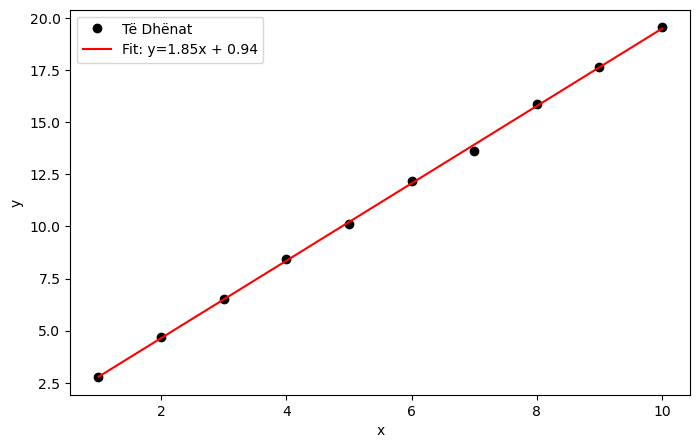

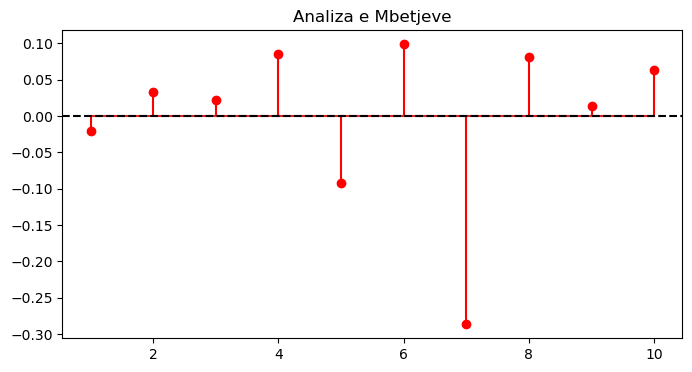

Rezultatet: a = 1.855, b = 0.936


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Hapi 3 - Ngarkimi
data = np.loadtxt("data/model.dat", delimiter=",", skiprows=1)
x_Data, y_Data = data[:, 0], data[:, 1]

# Hapi 4 - Përshtatja lineare
a, b = np.polyfit(x_Data, y_Data, 1)

# Hapi 5 - Vizualizimi
xfit = np.linspace(min(x_Data), max(x_Data), 100)
yfit = a * xfit + b

plt.figure(figsize=(8, 5))
plt.plot(x_Data, y_Data, 'ok', label='Të Dhënat')
plt.plot(xfit, yfit, '-r', label=f'Fit: y={a:.2f}x + {b:.2f}')
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

# Hapi 6 - Mbetjet (Residuals)
plt.figure(figsize=(8, 4))
plt.stem(x_Data, y_Data - (a*x_Data + b), linefmt='-r')
plt.axhline(0, color='k', ls='--')
plt.title("Analiza e Mbetjeve")
plt.show()

print(f"Rezultatet: a = {a:.3f}, b = {b:.3f}")

## 3. Përfundime

Në mbyllje të këtij laboratori, konstatojmë se:
1. U arrit gjenerimi i të dhënave të riprodhueshme dhe unike bazuar në kredencialet e studentit.
2. Metoda e katrorëve më të vegjël (polyfit) u përdor me sukses për të gjetur parametrat optimalë të drejtëzës.
3. Analiza grafike konfirmoi cilësinë e modelit, duke treguar një mospërputhje minimale (mbetjet) midis modelit teorik dhe të dhënave eksperimentale.
4. Struktura e folderave u organizua sipas kërkesave: LAB05/data/model.dat.